## Chuẩn bị vấn đề

### Khai báo thư viện

In [1]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score

### Nạp dữ liệu

In [2]:
# Load data 
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

### Tiền xử lý dữ liệu (Data Preprocessing)

#### Tạo thêm các biến mới giúp mô hình phân tích chuẩn xác và mạnh hơn

- `Title` (tách ra từ Name): Phản ánh giới tính, địa vị, tầng lớp xã hội.
- `FamilySize` (gộp lại từ `SibSp` và `Parch`): Quy mô gia đình ảnh hưởng tỉ lệ sống, đi cùng thành viên gia đình có tỉ lệ sống sót cao hơn.
- `IsChild`: Đánh dấu trẻ em (dưới 12 tuổi). Trong Titanic, trẻ em thường được cứu trước theo nguyên tắc “women and children first”.
- `IsMother`: Đánh dấu phụ nữ trưởng thành có con đi cùng. Mẹ thường được ưu tiên cứu cùng con.

In [3]:
# Feature engineering
def extract_title(name):
    m = re.search(r',\s*([^\.]+)\.', name)
    return m.group(1).strip() if m else ''

title_map = {
    'Capt': 'Officer', 'Col': 'Officer', 'Major': 'Officer', 'Dr': 'Officer', 'Rev': 'Officer',
    'Don': 'Royalty', 'Sir': 'Royalty', 'Lady': 'Royalty', 'the Countess': 'Royalty', 'Jonkheer': 'Royalty', 'Dona': 'Royalty'
}

for df in [train_df, test_df]:
    # --- Title (Name) ---
    df['Title'] = df['Name'].apply(extract_title)
    df['Title'] = df['Title'].replace(['Mlle','Ms'],'Miss')
    df['Title'] = df['Title'].replace(['Mme'],'Mrs')
    df['Title'] = df['Title'].replace(title_map)
    rare = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
    df['Title'] = df['Title'].replace(list(rare), 'Other')

    # --- Family (SibSp/Parch) ---
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    # --- Special groups ---
    df['IsChild'] = (df['Age'] < 12).astype(int)
    df['IsMother'] = ((df['Sex'] == 'female') & (df['Parch'] > 0) & (df['Age'] > 18) & (df['Title'] == 'Mrs')).astype(int)

In [4]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsChild,IsMother
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,1,0,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,2,0,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr,1,0,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr,1,0,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs,3,0,1


#### Filling missing value

In [5]:
def display_missing_data(df):
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    percent = (missing / len(df)) * 100
    print(pd.DataFrame({'Missing Values': missing, 'Percent (%)': percent.round(2)}))


In [6]:
display_missing_data(train_df)

          Missing Values  Percent (%)
Cabin                687        77.10
Age                  177        19.87
Embarked               2         0.22


- Trong file train.csv, `Embarked` chỉ có 2 giá trị bị thiếu (NaN) trên tổng 891 dòng —
tức là 0.2% dữ liệu → rất ít, không ảnh hưởng lớn đến phân phối.
- Chọn mode() là giá trị xuất hiện nhiều nhất trong cột để điền "giá trị đại diện" cho `Embarked`.

In [7]:
display_missing_data(test_df)

       Missing Values  Percent (%)
Cabin             327        78.23
Age                86        20.57
Fare                1         0.24


- Fare chỉ thiếu 1 giá trị → nên điền theo median. Median (trung vị) phản ánh mức trung tâm thực tế hơn cho dữ liệu lệch, vì nó không bị ảnh hưởng bởi các giá trị cực trị.

In [8]:
def best_features_for_imputation(df, target='Age', top=10):
    """
    Phân tích mối tương quan giữa 1 feature (vd: Age)
    với tất cả các feature khác trong dataframe để gợi ý 
    nên dùng cột nào để điền missing values.
    """
    corrs = {}
    for col in df.columns:
        if col == target:
            continue

        try:
            # Nếu là numeric -> dùng Spearman correlation
            if np.issubdtype(df[col].dropna().dtype, np.number):
                corr = spearmanr(df[target], df[col], nan_policy='omit')[0]
            else:
                # Nếu là object -> factorize (chuyển sang mã số)
                corr = spearmanr(df[target], pd.factorize(df[col])[0], nan_policy='omit')[0]
            corrs[col] = abs(corr)
        except Exception as e:
            continue

    # Sắp xếp giảm dần
    corrs_sorted = pd.Series(corrs).sort_values(ascending=False)
    result = corrs_sorted.head(top).to_frame('Spearman Corr (|r|)')
    print(f"\nTop {top} features liên quan mạnh nhất đến '{target}':\n")
    print(result)

    # --- Vẽ heatmap ---
    plt.figure(figsize=(8, max(4, top * 0.3)))
    sns.heatmap(result.T, annot=True, cmap='YlGnBu', fmt=".2f", cbar=False)
    plt.title(f"Top Correlations with {target}", fontsize=13)
    plt.xlabel("Features")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


Top 10 features liên quan mạnh nhất đến 'Fare':

            Spearman Corr (|r|)
Pclass                 0.688032
Cabin                  0.532923
FamilySize             0.528907
SibSp                  0.447113
Parch                  0.410074
Survived               0.323736
Title                  0.303792
Sex                    0.259593
Ticket                 0.258902
IsMother               0.183694


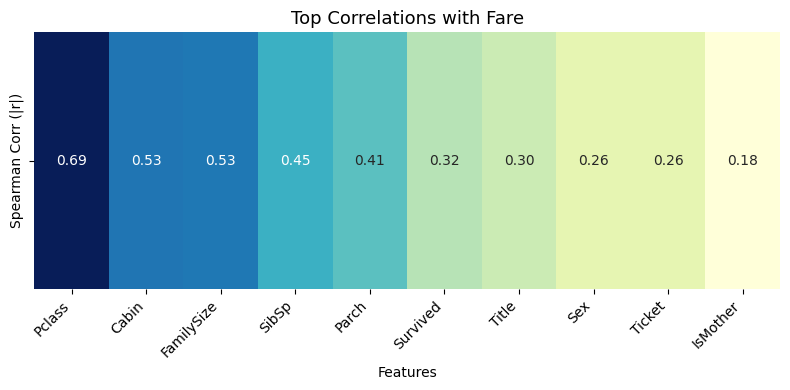

In [9]:
best_features_for_imputation(train_df, target='Fare', top=10)

- Ta thấy Pclass liên quan mạnh nhất đến `Fare` nên điền missing value của `Fare` bằng median trong từng nhóm Pclass.

Qua phân tích, ta nhận thấy một số đặc trưng có mối quan hệ chặt chẽ với `Age`:
- `Pclass`: Hạng vé, đại diện cho tầng lớp xã hội – hành khách ở hạng cao (Pclass=1) thường lớn tuổi hơn.
- `Title` (Mr, Miss, Dr, Master...): Phản ánh rõ độ tuổi và vai trò xã hội.
- Master thường dùng cho bé trai → tuổi nhỏ.
- Miss thường là phụ nữ trẻ chưa lập gia đình.
- Mrs thường là phụ nữ đã lập gia đình → lớn tuổi hơn Miss.
- Dr, Rev, Col... thường là người trưởng thành, có học vấn hoặc địa vị.

- `Sex`: Giới tính ảnh hưởng đến độ tuổi trung bình trong từng tầng lớp xã hội.
khi điền các giá trị thiếu của Age, việc nhóm theo `Sex + Pclass + Title` là lựa chọn tối ưu, giúp ước lượng tuổi gần sát thực tế và duy trì mối quan hệ tự nhiên giữa các đặc trưng.

In [10]:
# Fill missing values
for df in [train_df, test_df]:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    df['Fare'] = df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
    
    df['Age'] = df.groupby(['Sex','Pclass','Title'])['Age'].transform(lambda x: x.fillna(x.median()))

    # --- Chuẩn hóa log ---
    df['Fare'] = np.log1p(df['Fare'])
    df['Age'] = np.log1p(df['Age'])

Việc chuẩn hóa log giúp giảm độ lệch, ổn định mô hình, và giảm ảnh hưởng của các giá trị cực lớn trong `Fare` và `Age`.

####  Feature Engineering (Các biến khác)

In [11]:
for df in [train_df, test_df]:
    
    df['HasCabin'] = df['Cabin'].notna().astype(int)

    df['Age*Pclass'] = df['Age'] * df['Pclass']

    # --- Cabin / Deck ---
    df['Deck'] = df['Cabin'].astype(str).str[0]
    df['Deck'] = df['Deck'].replace('n', 'U')  # 'U' = Unknown

    # --- Interaction features ---
    df['Fare_Pclass'] = df['Fare'] / df['Pclass']

    df['TicketPrefix'] = df['Ticket'].apply(lambda x: re.split(r'\s|\.', str(x))[0])
    df['TicketPrefix'] = df['TicketPrefix'].apply(lambda x: x if x.isalpha() else 'NUM')

- `HasCabin`: Có Cabin hay không. Người có cabin → hạng vé cao → tầng lớp giàu có.
- `Deck`: Boong tàu – ký tự đầu của Cabin (A, B, C, D...). Deck thấp → gần đáy tàu → nguy hiểm hơn.
- `Age*Pclass`: Kết hợp tuổi và hạng vé – phản ánh tầng lớp xã hội theo tuổi.
- `Fare_Pclass`: Giá vé chia theo hạng vé.
- `TicketPrefix`: Phần đầu của mã vé cho biết hãng tàu hoặc loại vé.

In [12]:
# Prepare features
feature_cols = [
    'Pclass','Sex','Age','Fare','Embarked','Title','FamilySize','IsChild','IsMother',
    'Deck','HasCabin','Fare_Pclass','Age*Pclass','TicketPrefix'
]
x = train_df[feature_cols]
y = train_df['Survived']
x_test_final = test_df[feature_cols]

- Đoạn code trên chọn ra các biến đầu vào quan trọng nhất sau khi xử lý dữ liệu và tạo feature mới.
- Tập dữ liệu x chứa các đặc trưng này, trong khi y là biến mục tiêu `Survived`.
- Tập x_test_final được chuẩn bị tương tự để dự đoán kết quả cuối cùng.

#### Lưu dữ liệu features

In [16]:
exps_dir = "../exps"
if os.path.exists(exps_dir) == False: # tạo thư mục (nếu chưa có)
  os.makedirs(exps_dir, exist_ok=True)

save_dir = f"{exps_dir}/feature1"
os.makedirs(save_dir, exist_ok=True)
np.savez(f'{save_dir}/feat_preprocess.npz', x_train = x, y_train = y, x_test = x_test_final)

train_df.to_excel(f'{save_dir}/train_df_preprocess.xlsx', index=False)
test_df.to_excel(f'{save_dir}/test_df_preprocess.xlsx', index=False)

# Lưu cột đặc trưng 
np.savez(f'{save_dir}/feature_columns.npz', feature_columns = feature_cols)
dict(np.load(f'{save_dir}/feature_columns.npz'))

{'feature_columns': array(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize',
        'IsChild', 'IsMother', 'Deck', 'HasCabin', 'Fare_Pclass',
        'Age*Pclass', 'TicketPrefix'], dtype='<U12')}

### Preprocess pipeline

In [17]:
# Preprocessor (ColumnTransformer)
num_features = [
    'Age','Fare','FamilySize','Fare_Pclass','Age*Pclass'
]
cat_features = [
    'Pclass','Sex','Embarked','Title','IsChild','IsMother',
    'Deck','HasCabin','TicketPrefix'
]

num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', num_transformer, num_features), ('cat', cat_transformer, cat_features)])

- `num_features`: Các biến số cần được chuẩn hóa (StandardScaler) để đưa về cùng thang đo, tránh mô hình bị lệch bởi các giá trị lớn.

- `cat_features`: Các biến phân loại (category) cần được mã hóa (OneHotEncoder) để mô hình có thể hiểu được
- Biến số: điền điền median → chuẩn hóa thang đo.
- Biến phân loại: điền giá trị phổ biến nhất → one-hot encoding.

Dùng `ColumnTransformer` để gộp tất cả trong một bước, giúp mô hình hóa dễ dàng và nhất quán.

### Preprocess pipeline

In [15]:
# Preprocessor (ColumnTransformer)
num_features = [
    'Age','Fare','FamilySize','Fare_Pclass','Age*Pclass'
]
cat_features = [
    'Pclass','Sex','Embarked','Title','IsChild','IsMother',
    'Deck','HasCabin','TicketPrefix'
]

num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', num_transformer, num_features), ('cat', cat_transformer, cat_features)])

# Kết thúc